# Employee Attrition Prediction using Artificial Neural Networks (ANN)

## Problem Statement

Employee attrition is a critical challenge for organizations as high turnover leads to increased recruitment costs, productivity loss, and reduced employee morale.

The objective of this project is to build an Artificial Neural Network (ANN) model capable of predicting whether an employee is likely to leave the organization based on demographic, job-related, and performance-related attributes.

## Objectives

- Perform Exploratory Data Analysis (EDA)
- Preprocess and encode categorical features
- Build an ANN using TensorFlow/Keras
- Evaluate model performance
- Save trained artifacts for deployment
- Create an inference pipeline for future predictions

## Importing libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

## Load the dataset

In [4]:
df = pd.read_csv("HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.isnull().sum().sum()

np.int64(0)

## Data cleaning

In [9]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [10]:
df['Attrition'].value_counts(normalize=True)*100

,proportion
Attrition,
No,83.877551
Yes,16.122449


In [11]:
# check constant columns

for col in df.columns:
    print(col, ":", df[col].nunique())

Age : 43
Attrition : 2
BusinessTravel : 3
DailyRate : 886
Department : 3
DistanceFromHome : 29
Education : 5
EducationField : 6
EmployeeCount : 1
EmployeeNumber : 1470
EnvironmentSatisfaction : 4
Gender : 2
HourlyRate : 71
JobInvolvement : 4
JobLevel : 5
JobRole : 9
JobSatisfaction : 4
MaritalStatus : 3
MonthlyIncome : 1349
MonthlyRate : 1427
NumCompaniesWorked : 10
Over18 : 1
OverTime : 2
PercentSalaryHike : 15
PerformanceRating : 2
RelationshipSatisfaction : 4
StandardHours : 1
StockOptionLevel : 4
TotalWorkingYears : 40
TrainingTimesLastYear : 7
WorkLifeBalance : 4
YearsAtCompany : 37
YearsInCurrentRole : 19
YearsSinceLastPromotion : 16
YearsWithCurrManager : 18


In [12]:
# check categorical columns

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print("\n",col)
    print(df[col].unique())


 Attrition
['Yes' 'No']

 BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

 Department
['Sales' 'Research & Development' 'Human Resources']

 EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

 Gender
['Female' 'Male']

 JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

 MaritalStatus
['Single' 'Married' 'Divorced']

 Over18
['Y']

 OverTime
['Yes' 'No']


In [13]:
df = df.drop(
    columns=[
        'EmployeeCount',
        'Over18',
        'StandardHours',
        'EmployeeNumber'
    ]
)

df.shape

(1470, 31)

## EDA

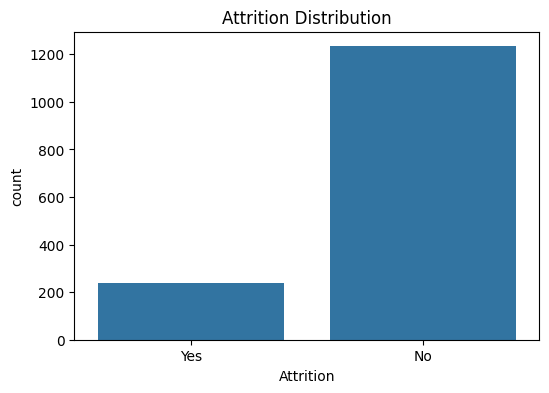

In [14]:
# Target distribution

plt.figure(figsize=(6,4))
sns.countplot(
    x='Attrition',
    data=df
)
plt.title('Attrition Distribution')
plt.show()

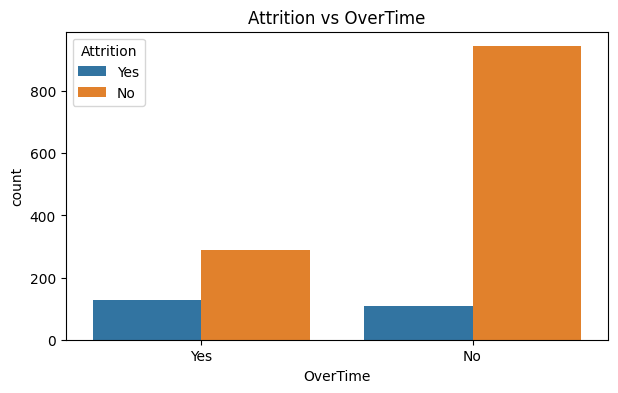

In [15]:
# Attrition vs Overtime

plt.figure(figsize=(7,4))
sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df
)
plt.title('Attrition vs OverTime')
plt.show()

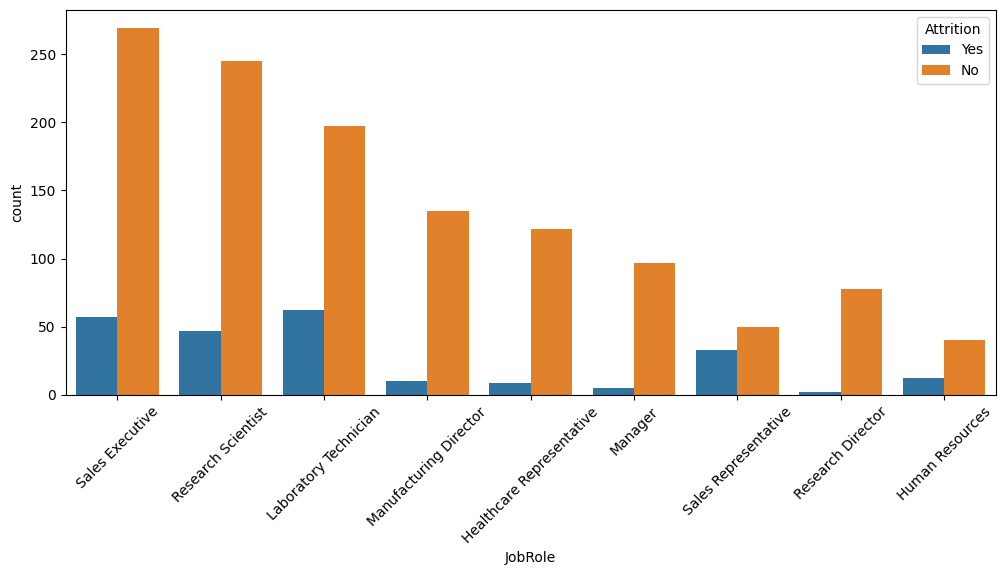

In [16]:
# Attrition vs JobRole

plt.figure(figsize=(12,5))
sns.countplot(
    x='JobRole',
    hue='Attrition',
    data=df
)
plt.xticks(rotation=45)
plt.show()

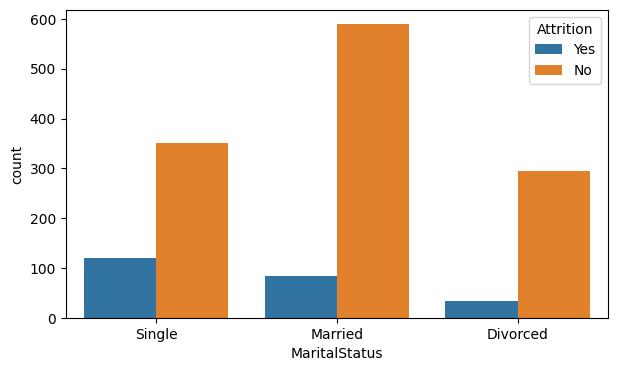

In [17]:
# Attrition vs Marital Status

plt.figure(figsize=(7,4))
sns.countplot(
    x='MaritalStatus',
    hue='Attrition',
    data=df
)
plt.show()

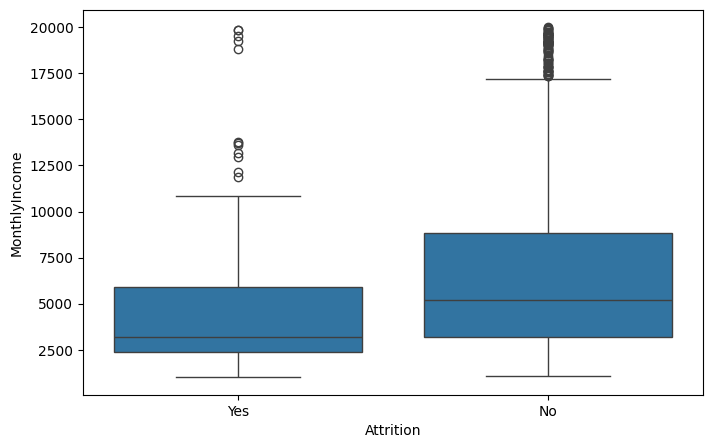

In [18]:
# Monthly Income vs Attrition

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)
plt.show()

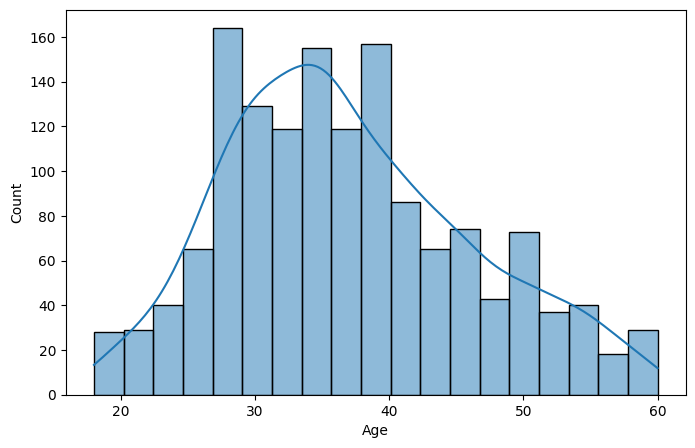

In [19]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df['Age'],
    kde=True
)
plt.show()

## Feature Engineering and Encoding

In [20]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [21]:
# Encode targets

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [22]:
# One hot encode features

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

In [23]:
X.shape

(1470, 44)

In [24]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,0,1,0,0,1,1
1,49,279,8,1,3,61,2,2,2,5130,...,0,0,0,0,1,0,0,1,0,0
2,37,1373,2,2,4,92,2,1,3,2090,...,1,0,0,0,0,0,0,0,1,1
3,33,1392,3,4,4,56,3,1,3,2909,...,0,0,0,0,1,0,0,1,0,1
4,27,591,2,1,1,40,3,1,2,3468,...,1,0,0,0,0,0,0,1,0,0


## Train Test Split

In [25]:
# Using stratification because target is unbalanced

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
print(X_train.shape)
print(X_test.shape)

(1176, 44)
(294, 44)


## Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# checking for scaled values

X_train[:2]

array([[ 1.09019402,  1.04945488, -0.89991452,  1.06420933, -0.65870975,
        -0.90843647,  1.79528209,  1.76218896, -0.64799683,  2.02675233,
         0.93128918,  1.33076293, -0.33712854, -0.43206495,  0.24021828,
         2.61310031,  2.26148214, -0.60538935,  0.33762109, -0.66570587,
        -0.62536487, -0.36802436, -0.6164065 , -0.48640833,  0.64829766,
        -1.36175216,  1.49357599,  1.2062814 , -0.35860682, -0.66953406,
        -0.23591375, -0.3292238 , -1.22128024, -0.19006143, -0.47299607,
         3.62886686, -0.32604128, -0.23791548, -0.479714  , -0.54984141,
        -0.23186945, -0.92144268, -0.68154831, -0.63772923],
       [-1.6348276 , -0.52344929, -0.89991452, -1.85533229,  0.26020207,
         1.69411125,  0.37356375, -0.98626491,  1.15352627, -0.8644084 ,
         0.68274179, -1.08370434, -0.33712854, -0.43206495,  0.24021828,
         0.24742982, -1.07267466, -0.60538935,  0.33762109, -0.83007079,
        -0.9056351 , -0.05688371, -0.89704685, -0.48640833,  0.

# Buidling ANN (version #1)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(
    64,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

model.add(Dropout(0.3))

model.add(Dense(
    32,
    activation='relu'
))

model.add(Dropout(0.3))

model.add(Dense(
    16,
    activation='relu'
))

model.add(Dense(
    1,
    activation='sigmoid'
))

## Model summary

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,505 (21.50 KB)

 Trainable params: 5,505 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

## Before training

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

## Compile the model

In [42]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model training

In [43]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.8840 - loss: 0.2686 - val_accuracy: 0.8898 - val_loss: 0.3294
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8830 - loss: 0.2666 - val_accuracy: 0.8771 - val_loss: 0.3347
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9000 - loss: 0.2647 - val_accuracy: 0.8856 - val_loss: 0.3378
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8979 - loss: 0.2580 - val_accuracy: 0.8814 - val_loss: 0.3321
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8915 - loss: 0.2467 - val_accuracy: 0.8856 - val_loss: 0.3330
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9043 - loss: 0.2409 - val_accuracy: 0.8856 - val_loss: 0.3309
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9074 - loss: 0.2292 - val_accuracy: 0.8771 - val_loss: 0.3410
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9021 - loss: 0.2337 - val_accuracy: 0.8856 - 

## After training

In [44]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot accuracy curve

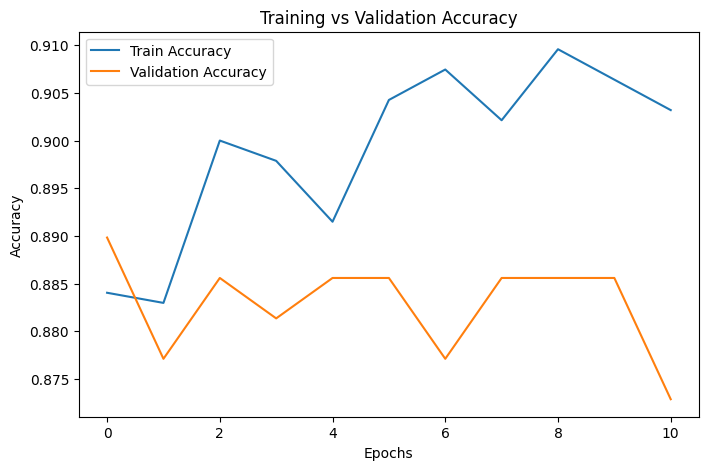

In [45]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Plot loss curve

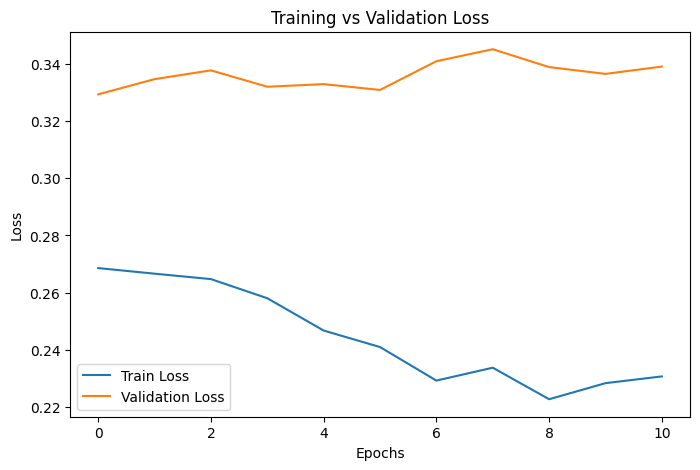

In [46]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [47]:
len(history.history['loss'])

11

## Model evaluation

In [48]:
# predictions

y_prob = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


In [49]:
# convert probabilities to classes

y_pred = (y_prob > 0.5).astype(int)

In [50]:
y_pred = y_pred.flatten()

### Accuracy

In [52]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8639455782312925

### Precision

In [53]:
precision_score(y_test, y_pred)

0.6

### Recall

In [54]:
recall_score(y_test, y_pred)

0.44680851063829785

### F1 score

In [55]:
f1_score(y_test, y_pred)

0.5121951219512195

### Classification report

In [56]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       247
           1       0.60      0.45      0.51        47

    accuracy                           0.86       294
   macro avg       0.75      0.70      0.72       294
weighted avg       0.85      0.86      0.86       294



### Confusion matrix

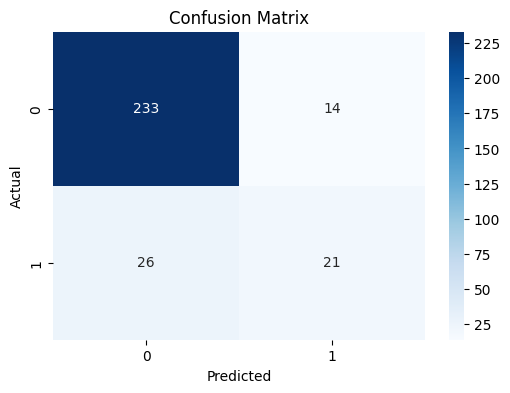

In [57]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

The model is good at predicting: Employee will stay

but not great at predicting: Employee will leave

hence dataset is imbalanced.



# Building ANN (Version #2)

In [58]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weights)

{0: np.float64(0.5963488843813387), 1: np.float64(3.094736842105263)}


### Retraining the model

In [59]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy: 0.8628 - loss: 0.4730 - val_accuracy: 0.7500 - val_loss: 0.4808
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8043 - loss: 0.4272 - val_accuracy: 0.7627 - val_loss: 0.4731
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8362 - loss: 0.3851 - val_accuracy: 0.7966 - val_loss: 0.4225
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8447 - loss: 0.3915 - val_accuracy: 0.7966 - val_loss: 0.4438
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8287 - loss: 0.3943 - val_accuracy: 0.8008 - val_loss: 0.4275
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8457 - loss: 0.3564 - val_accuracy: 0.8136 - val_loss: 0.4335
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8415 - loss: 0.3512 - val_accuracy: 0.8008 - val_loss: 0.4345
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8372 - loss: 0.3309 - val_accuracy: 0.7839 -

In [60]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)
y_pred = y_pred.flatten()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [61]:
accuracy_score(y_test, y_pred)

precision_score(y_test, y_pred)

recall_score(y_test, y_pred)

f1_score(y_test, y_pred)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.79      0.86       247
           1       0.39      0.70      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.78      0.80       294



## Tuning

In [62]:
y_pred = (y_prob > 0.5).astype(int)

In [63]:
for threshold in [0.3,0.4,0.5,0.6]:

    y_pred = (y_prob > threshold).astype(int)
    y_pred = y_pred.flatten()

    print(f"\nThreshold = {threshold}")
    print("Precision:", precision_score(y_test,y_pred))
    print("Recall:", recall_score(y_test,y_pred))
    print("F1:", f1_score(y_test,y_pred))


Threshold = 0.3
Precision: 0.24342105263157895
Recall: 0.7872340425531915
F1: 0.37185929648241206

Threshold = 0.4
Precision: 0.2857142857142857
Recall: 0.723404255319149
F1: 0.40963855421686746

Threshold = 0.5
Precision: 0.39285714285714285
Recall: 0.7021276595744681
F1: 0.5038167938931297

Threshold = 0.6
Precision: 0.4507042253521127
Recall: 0.6808510638297872
F1: 0.5423728813559322


| Model                   | Accuracy | Precision | Recall | F1       |
| ----------------------- | -------- | --------- | ------ | -------- |
| ANN V1                  | 86%      | 0.60      | 0.45   | 0.51     |
| ANN V2 (Class Weighted) | 78%      | 0.39      | 0.70   | 0.50     |
| ANN V2 + Threshold 0.6  | ~80%     | 0.45      | 0.68   | **0.54** |


### Conclusion

Class weighting significantly improved recall for attrition detection. Threshold tuning further improved the Precision-Recall tradeoff and produced the highest F1 score.

## Saving the model

In [64]:
model.save("employee_attrition_ann.keras")

In [65]:
# save scaler

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [66]:
# save label encoder

joblib.dump(
    le,
    "label_encoder.pkl"
)

['label_encoder.pkl']

In [70]:
sample = X.iloc[[0]]

sample_scaled = scaler.transform(sample)

probability = model.predict(sample_scaled)[0][0]

prediction = "Leave" if probability > 0.6 else "Stay"

print(f"Probability: {probability:.4f}")
print(f"Prediction: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Probability: 0.7894
Prediction: Leave


## ROC - AUC

In [72]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
AUC Score: 0.7852


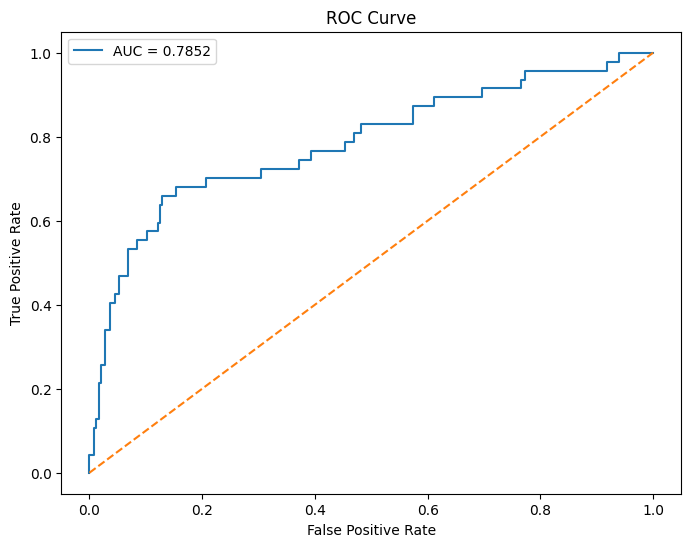

In [73]:
# plotting the curve

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

## Conclusion

Developed an ANN-based Employee Attrition Prediction System using TensorFlow/Keras.

Key achievements:

- Performed EDA and feature engineering on HR analytics data.
- Built a deep neural network with Dropout regularization.
- Addressed class imbalance using class weights.
- Improved minority-class detection through threshold tuning.
- Achieved strong recall for employee attrition prediction.
- Implemented model persistence and inference pipeline for future deployment.